In [141]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import json
import datetime

In [142]:
data_path = Path('data')/Path('sneakers_data.json')

In [143]:
with open(data_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.json_normalize(data)

df.head()

,slug,url,scraped_at,sales_series,errors,product_details.title,product_details.brand,product_details.traits.style,product_details.traits.colorway,product_details.traits.retail_price,...,_meta.retail_price,_meta.release_date,_meta.brand,_meta.title,_meta.series_count,_meta.has_errors,product_details.traits.included_accessories,product_details.traits.restock_date,product_details.traits.season,product_details.traits.color
0,air-jordan-1-low-midnight-navy-neutral-grey,https://stockx.com/air-jordan-1-low-midnight-n...,2026-06-17T03:25:27.852404+00:00,"[{'xValue': '2025-03-13T00:00:00.000Z', 'yValu...",[],Jordan 1 LowMidnight Navy Neutral Grey,None,553558-146,White/Neutral Grey/Gum Medium Brown/Midnight Navy,$125,...,$125,04/20/2025,None,Jordan 1 LowMidnight Navy Neutral Grey,100,False,NaN,NaN,NaN,NaN
1,air-jordan-1-retro-high-og-shattered-backboard...,https://stockx.com/air-jordan-1-retro-high-og-...,2026-06-16T02:53:09.759227+00:00,"[{'xValue': '2025-06-26T00:00:00.000Z', 'yValu...",[],Jordan 1 Retro High OGShattered Backboard (2025),None,DZ5485-008,Black/Black-Sail-Starfish,$180,...,$180,08/23/2025,None,Jordan 1 Retro High OGShattered Backboard (2025),100,False,Orange Laces,NaN,NaN,NaN
2,air-jordan-1-retro-high-og-sp-fragment-x-union...,https://stockx.com/air-jordan-1-retro-high-og-...,2026-06-16T02:53:12.844689+00:00,"[{'xValue': '2026-02-01T00:00:00.000Z', 'yValu...",[],Jordan 1 Retro High OG SPFragment x Union LA V...,None,IO7847-002,Black/White/Varsity Red/Sport Royal,$205,...,$205,02/27/2026,None,Jordan 1 Retro High OG SPFragment x Union LA V...,100,False,"Black Laces, Yellow Laces, Black/Red Laces",NaN,NaN,NaN
3,air-jordan-1-retro-high-virgil-abloh-archive-a...,https://stockx.com/air-jordan-1-retro-high-vir...,2026-06-16T02:53:17.434157+00:00,"[{'xValue': '2026-03-06T00:00:00.000Z', 'yValu...",[],Jordan 1 Retro HighVirgil Abloh Archive Alaska,None,AA3834-100,White/White,$230,...,$230,04/03/2026,None,Jordan 1 Retro HighVirgil Abloh Archive Alaska,100,False,"Blue Zip Tie, Black Laces, Purple Laces, Blue ...",NaN,NaN,NaN
4,air-jordan-1-retro-low-og-banned,https://stockx.com/air-jordan-1-retro-low-og-b...,2026-06-17T03:26:09.020156+00:00,"[{'xValue': '2026-04-09T00:00:00.000Z', 'yValu...",[],Jordan 1 Retro Low OGBanned,None,IW6276-001,Black/Black/Varsity Red/Summit White,$145,...,$145,05/02/2026,None,Jordan 1 Retro Low OGBanned,100,False,"White Laces, Red Laces",NaN,NaN,NaN


# Clean Data

In [144]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5013 entries, 0 to 5012
Data columns (total 25 columns):
 #   Column                                       Non-Null Count  Dtype 
---  ------                                       --------------  ----- 
 0   slug                                         5013 non-null   str   
 1   url                                          5013 non-null   str   
 2   scraped_at                                   5013 non-null   str   
 3   sales_series                                 5013 non-null   object
 4   errors                                       5013 non-null   object
 5   product_details.title                        5009 non-null   str   
 6   product_details.brand                        0 non-null      object
 7   product_details.traits.style                 4988 non-null   str   
 8   product_details.traits.colorway              4981 non-null   str   
 9   product_details.traits.retail_price          4984 non-null   str   
 10  product_details.traits.

## General Quality

In [145]:
df.shape

(5013, 25)

In [146]:
df['product_details.source'].value_counts()

product_details.source
html_section    5009
not_found          4
Name: count, dtype: int64

In [147]:
df.drop(df[df['product_details.source'] == 'not_found'].index, inplace=True)

In [148]:
df[df['product_details.source'] == 'not_found']

,slug,url,scraped_at,sales_series,errors,product_details.title,product_details.brand,product_details.traits.style,product_details.traits.colorway,product_details.traits.retail_price,...,_meta.retail_price,_meta.release_date,_meta.brand,_meta.title,_meta.series_count,_meta.has_errors,product_details.traits.included_accessories,product_details.traits.restock_date,product_details.traits.season,product_details.traits.color


In [149]:
len(df[df['_meta.has_errors']== True])

4

In [150]:
df.drop(df[df['_meta.has_errors']== True].index, inplace=True)

In [151]:
len(df[df['_meta.has_errors']== True])

0

Only 8 rows has been deleted

## Looking for NaNs

In [152]:
df.isna().sum()

slug                                              0
url                                               0
scraped_at                                        0
sales_series                                      0
errors                                            0
product_details.title                             0
product_details.brand                          5005
product_details.traits.style                     21
product_details.traits.colorway                  28
product_details.traits.retail_price              25
product_details.traits.release_date             365
product_details.description                    2006
product_details.source                            0
_meta.style                                      21
_meta.colorway                                   28
_meta.retail_price                               25
_meta.release_date                              365
_meta.brand                                    5005
_meta.title                                       0
_meta.series

## Use only the most interesting columns

In [153]:
columns_to_use = [
    'sales_series',
    'product_details.title',
    'product_details.traits.retail_price',
    'product_details.traits.release_date'
    ]

In [154]:
df = df[columns_to_use]
df.head()

,sales_series,product_details.title,product_details.traits.retail_price,product_details.traits.release_date
0,"[{'xValue': '2025-03-13T00:00:00.000Z', 'yValu...",Jordan 1 LowMidnight Navy Neutral Grey,$125,04/20/2025
1,"[{'xValue': '2025-06-26T00:00:00.000Z', 'yValu...",Jordan 1 Retro High OGShattered Backboard (2025),$180,08/23/2025
2,"[{'xValue': '2026-02-01T00:00:00.000Z', 'yValu...",Jordan 1 Retro High OG SPFragment x Union LA V...,$205,02/27/2026
3,"[{'xValue': '2026-03-06T00:00:00.000Z', 'yValu...",Jordan 1 Retro HighVirgil Abloh Archive Alaska,$230,04/03/2026
4,"[{'xValue': '2026-04-09T00:00:00.000Z', 'yValu...",Jordan 1 Retro Low OGBanned,$145,05/02/2026


In [155]:
df.columns = df.columns.str.replace(r'^product_details\.', '', regex=True)
df.columns = df.columns.str.replace(r'^traits\.', '', regex=True)

nuevas_columnas = ['title'] + [col for col in df.columns if col != 'title']
df = df[nuevas_columnas]

df.head()

,title,sales_series,retail_price,release_date
0,Jordan 1 LowMidnight Navy Neutral Grey,"[{'xValue': '2025-03-13T00:00:00.000Z', 'yValu...",$125,04/20/2025
1,Jordan 1 Retro High OGShattered Backboard (2025),"[{'xValue': '2025-06-26T00:00:00.000Z', 'yValu...",$180,08/23/2025
2,Jordan 1 Retro High OG SPFragment x Union LA V...,"[{'xValue': '2026-02-01T00:00:00.000Z', 'yValu...",$205,02/27/2026
3,Jordan 1 Retro HighVirgil Abloh Archive Alaska,"[{'xValue': '2026-03-06T00:00:00.000Z', 'yValu...",$230,04/03/2026
4,Jordan 1 Retro Low OGBanned,"[{'xValue': '2026-04-09T00:00:00.000Z', 'yValu...",$145,05/02/2026


In [156]:
df.isna().sum()

title             0
sales_series      0
retail_price     25
release_date    365
dtype: int64

### Drop useless sneakers

A sneaker is useless if it hasn't data about sales_series, retail_price and release_date

In [157]:
df[df['retail_price'].isna()]

,title,sales_series,retail_price,release_date
280,adidas Samba OGBambi Brown Desert (Women's),"[{'xValue': '2026-05-31T00:00:00.000Z', 'yValu...",NaN,NaN
756,adidas Superstar IIAnthony Edwards Navy Croc,"[{'xValue': '2026-02-01T00:00:00.000Z', 'yValu...",NaN,NaN
1533,Jordan 1 MidBlack Cool Grey Light Armoury Blue,"[{'xValue': '2026-04-26T00:00:00.000Z', 'yValu...",NaN,10/01/2022
1699,ASICS Superblast 3blacktoes Keep Running Quiet,"[{'xValue': '2026-05-30T00:00:00.000Z', 'yValu...",NaN,06/30/2026
2292,ASICS Gel-Kahana TR V4Ocean Green,"[{'xValue': '2024-06-22T00:00:00.000Z', 'yValu...",NaN,03/18/2024
2761,New Balance 740Timberwolf White,"[{'xValue': '2025-12-05T00:00:00.000Z', 'yValu...",NaN,NaN
3092,New Balance 997RCream,"[{'xValue': '2023-12-11T00:00:00.000Z', 'yValu...",NaN,NaN
3208,New Balance 1906Datmos Tokyo Deep Sea,"[{'xValue': '2024-12-21T00:00:00.000Z', 'yValu...",NaN,NaN
3215,New Balance 530Linen Stoneware,"[{'xValue': '2024-05-03T00:00:00.000Z', 'yValu...",NaN,NaN
3227,New Balance 9060Mono Black,"[{'xValue': '2025-12-10T00:00:00.000Z', 'yValu...",NaN,NaN


In [158]:
df.shape

(5005, 4)

In [159]:
condicion_lista_vacia = df['sales_series'].str.len() == 0
condicion_nulos = df['retail_price'].isna() & df['release_date'].isna()

filas_a_eliminar = condicion_lista_vacia & condicion_nulos

df_limpio = df[~filas_a_eliminar]

In [160]:
df_limpio.shape

(4996, 4)

In [161]:
df.shape[0] - df_limpio.shape[0] # only 9 rows were deleted

9

### Fill release_date using temporal series

In [162]:
df_limpio.isna().sum()

title             0
sales_series      0
retail_price     16
release_date    356
dtype: int64

In [163]:
df_limpio['release_date'].isna().sum()

np.int64(356)

In [164]:
(df_limpio['release_date'].isna().sum()/df_limpio.shape[0])*100

np.float64(7.125700560448359)

We cannot delete the 7% of the data

In [165]:
df_limpio[(df_limpio['release_date'].isna()) & (df_limpio['sales_series'].str.len() == 0)] # untrackable date, we delte them

,title,sales_series,retail_price,release_date
710,adidas Handball SpezialOlive Strata Acid Mint,[],$120,NaN
3156,New Balance 9060Lone Star,[],$150,NaN
4068,Nike Air Max 95 OGBig Bubble 7-Eleven,[],$210,NaN
4205,Puma Speedcat OGLilac Luster Lavender Pop,[],$100,NaN
4264,Puma Mostro MoveWhite Warm White (Women's),[],$120,NaN
...,...,...,...,...
4982,Puma CA MatchBMW Motorsport White Pro Blue,[],$90,NaN
4985,Puma Deviate Nitro 3Dusky Gray Heat Fire,[],$160,NaN
4990,Puma InhaleMint Melt Lavender Alert,[],$110,NaN
5000,Puma RoyalOrange Glo Black,[],$75,NaN


In [166]:
74/df_limpio.shape[0] * 100

1.4811849479583667

In [167]:
condicion_lista_vacia = df_limpio['sales_series'].str.len() == 0
condicion_nulos = df_limpio['release_date'].isna()

filas_a_eliminar = condicion_lista_vacia & condicion_nulos

df_limpio = df_limpio[~filas_a_eliminar]

#### Try to fill the gaps using the time serie

In [168]:
df_limpio[(df_limpio['release_date'].isna()) & (df_limpio['sales_series'].str.len() > 0)]

,title,sales_series,retail_price,release_date
244,adidas Samba JaneBeige Sand Strata (Women's),"[{'xValue': '2026-05-10T00:00:00.000Z', 'yValu...",$110,NaN
280,adidas Samba OGBambi Brown Desert (Women's),"[{'xValue': '2026-05-31T00:00:00.000Z', 'yValu...",NaN,NaN
281,adidas Samba OGBasketweave Black Cream White (...,"[{'xValue': '2026-04-15T00:00:00.000Z', 'yValu...",$100,NaN
346,adidas Handball SpezialCream White Coral Velve...,"[{'xValue': '2024-12-25T00:00:00.000Z', 'yValu...",$100,NaN
438,adidas Adistar Control 5White Black Brown,"[{'xValue': '2026-02-01T00:00:00.000Z', 'yValu...",$120,NaN
...,...,...,...,...
4983,Puma Club 5v5Black White Gold (Women's),"[{'xValue': '2026-04-08T00:00:00.000Z', 'yValu...",$70,NaN
4991,Puma InverseMutant Green Glare Black,"[{'xValue': '2025-12-15T00:00:00.000Z', 'yValu...",$100,NaN
5005,Puma Softride Remi Slip-OnAsh Gray White Rose ...,"[{'xValue': '2026-03-09T00:00:00.000Z', 'yValu...",$70,NaN
5007,Puma Speedcat OGTeam Light Blue Silver Sky (Wo...,"[{'xValue': '2026-03-27T00:00:00.000Z', 'yValu...",$100,NaN


In [169]:
def obtener_fecha_mas_antigua(lista_series):
    if isinstance(lista_series, list) and len(lista_series) > 0:
        fechas = [registro['xValue'] for registro in lista_series if 'xValue' in registro]
        if fechas:

            fecha_antiva = min(fechas)
            return fecha_antiva.split('T')[0]
    return None

mascara = (df_limpio['release_date'].isna()) & (df_limpio['sales_series'].str.len() > 0)

df_limpio.loc[mascara, 'release_date'] = df_limpio.loc[mascara, 'sales_series'].apply(obtener_fecha_mas_antigua)

In [170]:
df_limpio[(df_limpio['release_date'].isna())]

,title,sales_series,retail_price,release_date


In [171]:
df_limpio.isna().sum()

title            0
sales_series     0
retail_price    16
release_date     0
dtype: int64

## Fill retail_price using Median

In [172]:
df_limpio['retail_price'] = df_limpio['retail_price'].str.replace('$', '')
df_limpio['retail_price'] = df_limpio['retail_price'].str.replace(',', '', regex=False)
df_limpio['retail_price'] = df_limpio['retail_price'].astype('float')

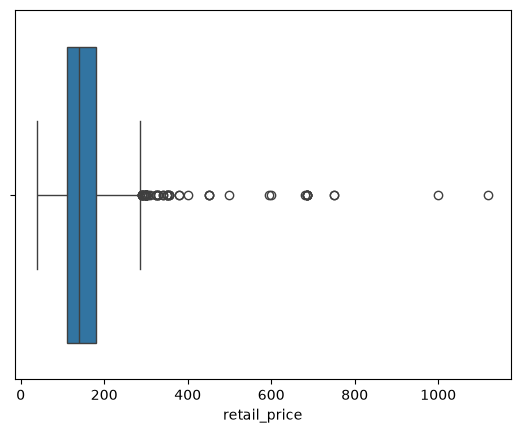

In [173]:
sns.boxplot(
    data=df_limpio,
    x='retail_price'
    )

plt.show()

In [174]:

valor_relleno = df_limpio['retail_price'].median() - df_limpio['retail_price'].std()


df_limpio['retail_price'] = df_limpio['retail_price'].fillna(valor_relleno)

In [175]:
df_limpio.isna().sum()

title           0
sales_series    0
retail_price    0
release_date    0
dtype: int64

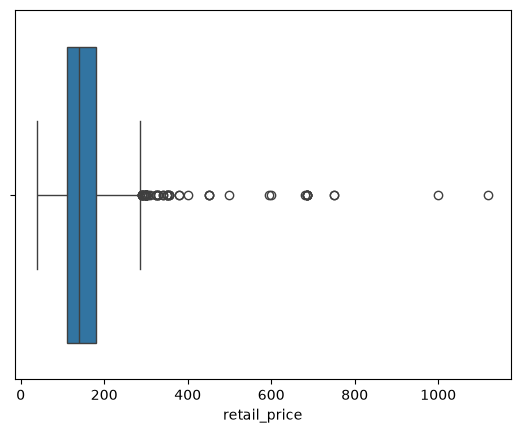

In [176]:
sns.boxplot(
    data=df_limpio,
    x='retail_price'
    )

plt.show()

### Drop sneakers without temporal data

In [177]:
df_limpio = df_limpio[~(df_limpio['sales_series'].str.len() == 0)]

In [178]:
df_limpio

,title,sales_series,retail_price,release_date
0,Jordan 1 LowMidnight Navy Neutral Grey,"[{'xValue': '2025-03-13T00:00:00.000Z', 'yValu...",125.0,04/20/2025
1,Jordan 1 Retro High OGShattered Backboard (2025),"[{'xValue': '2025-06-26T00:00:00.000Z', 'yValu...",180.0,08/23/2025
2,Jordan 1 Retro High OG SPFragment x Union LA V...,"[{'xValue': '2026-02-01T00:00:00.000Z', 'yValu...",205.0,02/27/2026
3,Jordan 1 Retro HighVirgil Abloh Archive Alaska,"[{'xValue': '2026-03-06T00:00:00.000Z', 'yValu...",230.0,04/03/2026
4,Jordan 1 Retro Low OGBanned,"[{'xValue': '2026-04-09T00:00:00.000Z', 'yValu...",145.0,05/02/2026
...,...,...,...,...
5007,Puma Speedcat OGTeam Light Blue Silver Sky (Wo...,"[{'xValue': '2026-03-27T00:00:00.000Z', 'yValu...",100.0,2026-03-27
5009,Puma Stewie 3 TeamTart Cherry (Women's),"[{'xValue': '2025-12-03T00:00:00.000Z', 'yValu...",120.0,08/01/2024
5010,Puma Talon OGFlat Light Grey,"[{'xValue': '2025-10-21T00:00:00.000Z', 'yValu...",150.0,2025-10-21
5011,Puma x Pokemon Kids' 28L BackpackPuma Black/St...,"[{'xValue': '2026-06-03T00:00:00.000Z', 'yValu...",75.0,04/02/2026


In [179]:
df = df_limpio